# Black-Scholes — From First Principles

## Why this matters

The Black-Scholes (BS) model is the foundation of derivatives pricing. Even though practitioners use stochastic-vol and local-vol extensions in production, BS is the **vocabulary** of the desk:

- **Implied volatility** is BS-inverted from market prices. The "vol surface" is a BS-quoted surface.
- **Greeks** are partial derivatives of the BS price. Hedging conversations happen in those units.
- **Put-call parity**, the no-arbitrage backbone, is a BS-derivable identity.

You will be asked, in some order, at almost every IB quant interview:

1. Derive the Black-Scholes PDE from a delta-hedged portfolio.
2. Derive BS as a risk-neutral expectation. Why are these equivalent?
3. State the closed-form formula and its assumptions.
4. Why does the price depend on σ but not μ?
5. What is $N(d_1)$? What is $N(d_2)$? They have different probabilistic interpretations — what are they?
6. Compute / explain put-call parity from a static replication argument.
7. What's the BS analogue when you only have the forward (Black-76)?
8. What does each Greek mean, and why is the ATM call delta NOT 0.5?

This notebook lands #1–6 with full derivations, and Black-76 (#7). Greeks (#8) are in `03_greeks.ipynb`. **Bachelier, SABR, and asset-class extensions (FX, fixed income) are in `02_bs_family_and_asset_classes.ipynb`.**

## The 30-second concept

A European call gives the right to buy a stock at strike `K` on date `T`. To price it without arbitrage, BS assumes:

1. The stock follows **geometric Brownian motion (GBM)** with constant drift μ and volatility σ.
2. Cash earns the risk-free rate `r` continuously.
3. No transaction costs; constant continuous dividend yield `q` (or zero); no early exercise.
4. The option can be **dynamically hedged** by trading the stock in continuous time.

Under those assumptions, you can build a portfolio of stock + bond that **exactly replicates** the option payoff, second by second. No-arbitrage forces the option price to equal the cost of that replicating portfolio.

The replication argument removes drift μ from the answer — only volatility σ matters.

> **Returning after a long break?** The next two derivations move fast through Itô's lemma, Girsanov, and risk-neutral measures. If those names don't immediately mean something, **skip ahead to the "Intuition first — see it before you derive it" section after Setup.** Watch the model and the hedging argument *work numerically*, then come back here. The math will read as a proof of something you've already seen, not as a wall of symbols.

## Derivation 1 — The Black-Scholes PDE via delta hedging

Stock dynamics under the **physical measure** P:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t^P$$

Let $V(S,t)$ be the option value. Build the portfolio:

$$\Pi_t = V(S_t, t) - \Delta_t \cdot S_t$$

Apply Itô's lemma to $V$:

$$dV = \left( \partial_t V + \mu S \, \partial_S V + \tfrac{1}{2}\sigma^2 S^2 \, \partial_{SS} V \right) dt + \sigma S \, \partial_S V \, dW^P$$

Therefore

$$d\Pi = \left( \partial_t V + \mu S \, \partial_S V + \tfrac{1}{2}\sigma^2 S^2 \, \partial_{SS} V - \Delta \mu S \right) dt + \sigma S \, (\partial_S V - \Delta) \, dW^P$$

**Choose** $\Delta = \partial_S V$. The $dW$ term cancels — Π is now locally riskless. By no-arbitrage, $d\Pi = r \Pi \, dt$:

$$\partial_t V + \tfrac{1}{2}\sigma^2 S^2 \, \partial_{SS} V + r S \, \partial_S V - rV = 0$$

This is the Black-Scholes PDE. With dividends, the carry term becomes $(r-q)S\partial_S V$.

Boundary at expiry: $V(S, T) = \max(S - K, 0)$ for a call.

> **Interview note**: The choice $\Delta = \partial_S V$ is *the* punchline. The $dW$ cancellation isn't algebraic luck — it's the specific reason the price doesn't depend on μ.

## Derivation 2 — Risk-neutral expectation

The PDE has a Feynman-Kac representation. Equivalently, by the **Fundamental Theorem of Asset Pricing**, there exists a measure Q (the risk-neutral measure) under which the *discounted* stock $\tilde S_t = e^{-(r-q)t} S_t$ is a martingale. Girsanov's theorem constructs Q by shifting the drift:

$$dS_t = (r - q) S_t \, dt + \sigma S_t \, dW_t^Q$$

Then the price of any European-style payoff $\Phi(S_T)$ is:

$$V(S_t, t) = e^{-r(T-t)} \, \mathbb{E}^Q \!\left[ \Phi(S_T) \,\big|\, \mathcal{F}_t \right]$$

For a call, $\Phi(S_T) = \max(S_T - K, 0)$. Under Q, $\ln S_T \sim \mathcal{N}\!\left(\ln S_t + (r - q - \tfrac{1}{2}\sigma^2)\tau, \, \sigma^2 \tau\right)$ where $\tau = T - t$. Splitting the integral:

$$C = \underbrace{e^{-r\tau} \mathbb{E}^Q[S_T \cdot \mathbf{1}_{S_T > K}]}_{\text{term 1}} - \underbrace{e^{-r\tau} K \cdot \mathbb{Q}(S_T > K)}_{\text{term 2}}$$

A change of measure (to the **stock-numéraire measure** $Q^S$) on term 1, and direct evaluation of the lognormal CDF on term 2, gives:

$$\boxed{\;C = S e^{-q\tau} N(d_1) - K e^{-r\tau} N(d_2)\;}$$

$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)\tau}{\sigma\sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}$$

For the put (by parity or direct computation):
$$P = K e^{-r\tau} N(-d_2) - S e^{-q\tau} N(-d_1)$$

### Probabilistic interpretation of $N(d_1)$ and $N(d_2)$

These are **not the same probability** — interviewers love this:

- **$N(d_2) = \mathbb{Q}(S_T > K)$** — the risk-neutral probability the call ends in the money.
- **$N(d_1) = \mathbb{Q}^S(S_T > K)$** — the same probability under the **stock-numéraire** measure, where the stock is the riskless asset. Equivalently, $S e^{-q\tau} N(d_1)$ is the (discounted) expected value of $S_T$ *conditional on the call finishing in the money*, weighted by that probability.

> **Interview note**: a common follow-up — "what's the delta of an ATM call?" People who say "0.5" haven't thought about this. The delta is $e^{-q\tau} N(d_1)$, and at the money $d_1 \approx \tfrac{1}{2}\sigma\sqrt{\tau} > 0$, so $N(d_1) > 0.5$. For a 1-year, 30-vol ATM call, delta is ≈ 0.56.

## Put-call parity — static replication argument

Don't memorise the formula. Build the portfolio:

| Position | Cash flow at time 0 | Cash flow at $T$ if $S_T > K$ | Cash flow at $T$ if $S_T \le K$ |
|---|---|---|---|
| Long call | $-C$ | $S_T - K$ | $0$ |
| Short put | $+P$ | $0$ | $-(K - S_T) = S_T - K$ |
| Short stock (with re-investment of dividends) | $+S e^{-q\tau}$ | $-S_T$ | $-S_T$ |
| Long zero-coupon bond paying $K$ | $-K e^{-r\tau}$ | $+K$ | $+K$ |

In every state at time $T$, the portfolio pays exactly **zero**. By no-arbitrage, the time-0 cost is also zero:

$$-C + P + S e^{-q\tau} - K e^{-r\tau} = 0$$

$$\boxed{\; C - P = S e^{-q\tau} - K e^{-r\tau} \;}$$

This holds **independent of any model** — pure static replication. Whenever you see violations of parity in market data, it's either a stale quote, a hard-to-borrow stock with implicit borrow cost, or a discrete dividend not properly accounted for.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import pickle
from pathlib import Path

# Real AAPL options snapshot (captured at build time via yfinance).
SNAPSHOT = Path('../data/aapl_options_snapshot.pkl')
with open(SNAPSHOT, 'rb') as f:
    snap = pickle.load(f)

S0       = snap['spot']
T_days   = snap['T_days']
T        = T_days / 365.0
spot_dt  = snap['spot_date']
expiry   = snap['expiry']
calls    = snap['calls']
puts     = snap['puts']

# Production: equity options discount on the OIS/SOFR curve, NOT T-bill yields.
# 28-day option uses the ~1M point on SOFR-OIS. Hardcoded teaching shortcut.
r = 0.043

# AAPL: discrete quarterly dividends. Continuous-q is valid only when no ex-date is in window.
q = 0.005

print(f'AAPL spot {spot_dt}: ${S0:.2f}')
print(f'expiry: {expiry}  ({T_days} days, T = {T:.4f}y)')
print(f'r = {r:.3f},  q = {q:.3f}')
print(f'calls: {len(calls)} strikes,  puts: {len(puts)} strikes')

AAPL spot 2026-05-01: $281.68
expiry: 2026-05-29  (28 days, T = 0.0767y)
r = 0.043,  q = 0.005
calls: 37 strikes,  puts: 31 strikes


# Intuition first — see it before you derive it

If the PDE and risk-neutral derivations above felt fast, this section is for you. We're going to build the BS argument from three numerical demos, in order:

1. **What does GBM actually look like?** — sample some paths and look at the terminal distribution.
2. **What is Itô's lemma really saying?** — verify the one rule `(dW)² = dt` by simulation.
3. **What does delta-hedging do?** — show that selling a call and dynamically delta-hedging collapses your P&L variance to (almost) zero. *That collapse is the entire point of BS.*

After this you'll be able to read the math above as the formal version of something you've watched happen.

## (1) What GBM actually looks like

GBM says: log returns are normal, with drift `(μ − ½σ²)` and standard deviation `σ` per unit of time. Equivalently, $S_T = S_0 \cdot \exp\!\big((\mu - \tfrac{1}{2}\sigma^2)T + \sigma\sqrt{T}\,Z\big)$ with `Z ~ N(0,1)`.

Two visual takeaways from the simulation below:

- **Paths look like noisy exponential drift.** Continuous, no jumps, no autocorrelation in returns.
- **The terminal distribution is lognormal — fat right tail, bounded below at zero.** That asymmetry alone is enough to give calls value even when the forward equals the strike.

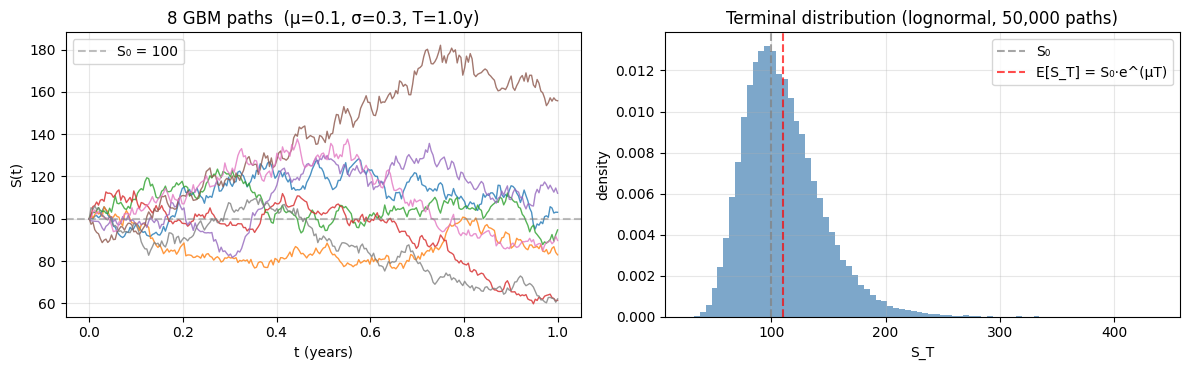

mean S_T (simulated): 110.544    theory E[S_T] = S₀·e^(μT) = 110.517
median S_T:           105.572    (lognormal median = S₀·e^((μ-½σ²)T) = 105.654)
P(S_T < S₀):          0.428    ← MORE than 50% even with positive drift, because of the σ²/2 drag


In [2]:
# Simulate GBM paths and the terminal distribution.
rng_demo  = np.random.default_rng(0)
S0_demo   = 100.0
mu_demo   = 0.10            # 10% drift
sig_demo  = 0.30            # 30% vol
T_demo    = 1.0             # 1 year
n_steps   = 252             # daily
dt_demo   = T_demo / n_steps

# Path simulation: log-Euler scheme (exact for GBM).
n_paths_show = 8
Z_paths      = rng_demo.standard_normal((n_paths_show, n_steps))
log_incs     = (mu_demo - 0.5 * sig_demo**2) * dt_demo + sig_demo * np.sqrt(dt_demo) * Z_paths
log_paths    = np.cumsum(log_incs, axis=1)
S_paths      = S0_demo * np.exp(np.concatenate([np.zeros((n_paths_show, 1)), log_paths], axis=1))
t_grid       = np.linspace(0, T_demo, n_steps + 1)

# Terminal distribution from many paths.
n_paths_hist = 50_000
Z_term       = rng_demo.standard_normal(n_paths_hist)
S_T          = S0_demo * np.exp((mu_demo - 0.5 * sig_demo**2) * T_demo + sig_demo * np.sqrt(T_demo) * Z_term)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for path in S_paths:
    axes[0].plot(t_grid, path, lw=1, alpha=0.8)
axes[0].axhline(S0_demo, color='gray', ls='--', alpha=0.5, label=f'S₀ = {S0_demo:.0f}')
axes[0].set_xlabel('t (years)'); axes[0].set_ylabel('S(t)')
axes[0].set_title(f'8 GBM paths  (μ={mu_demo}, σ={sig_demo}, T={T_demo}y)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(S_T, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='none')
axes[1].axvline(S0_demo, color='gray', ls='--', alpha=0.7, label='S₀')
axes[1].axvline(S0_demo * np.exp(mu_demo * T_demo), color='red', ls='--', alpha=0.7, label='E[S_T] = S₀·e^(μT)')
axes[1].set_xlabel('S_T'); axes[1].set_ylabel('density')
axes[1].set_title(f'Terminal distribution (lognormal, {n_paths_hist:,} paths)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'mean S_T (simulated): {S_T.mean():.3f}    theory E[S_T] = S₀·e^(μT) = {S0_demo*np.exp(mu_demo*T_demo):.3f}')
print(f'median S_T:           {np.median(S_T):.3f}    (lognormal median = S₀·e^((μ-½σ²)T) = {S0_demo*np.exp((mu_demo-0.5*sig_demo**2)*T_demo):.3f})')
print(f'P(S_T < S₀):          {(S_T < S0_demo).mean():.3f}    ← MORE than 50% even with positive drift, because of the σ²/2 drag')

## (2) Itô's lemma in one line: `(dW)² = dt`

Stochastic calculus differs from ordinary calculus in exactly **one** rule. For a Brownian increment $\Delta W$ over time step $\Delta t$:

- **Ordinary calculus:** $(\Delta t)^2 \to 0$ faster than $\Delta t$. So we drop second-order terms.
- **Stochastic calculus:** $(\Delta W)^2 \to \Delta t$, **not zero**. Second-order in $W$ is *first-order in time*.

That single fact is why a Taylor expansion of $f(W_t, t)$ produces the extra $\tfrac{1}{2} f_{WW}$ term — Itô's lemma. Everything in BS follows from this. Let's just check it numerically.

In [3]:
# Quadratic variation of Brownian motion: sum of (ΔW)² over [0,T] should converge to T.
# Compare with the analogous sum for a smooth deterministic path, which converges to 0.
rng_qv = np.random.default_rng(1)
T_qv   = 1.0

print(f'Target value: T = {T_qv:.4f}')
print(f'{"steps n":>10s} | {"Σ (ΔW)²  (Brownian)":>22s} | {"Σ (Δf)²  (smooth f=t)":>24s}')
print('-' * 64)
for n in [10, 100, 1_000, 10_000, 100_000]:
    dt = T_qv / n
    dW = np.sqrt(dt) * rng_qv.standard_normal(n)
    sum_dW2 = (dW ** 2).sum()

    # Smooth deterministic path f(t) = t for comparison.
    df = np.full(n, dt)
    sum_df2 = (df ** 2).sum()

    print(f'{n:>10d} | {sum_dW2:>22.6f} | {sum_df2:>24.6e}')

print('\nBrownian: Σ(ΔW)² → T (finite, nonzero).  Smooth: Σ(Δf)² → 0.')
print('That gap is what forces the extra ½σ²S²·∂²V/∂S² term in Itô / the BS PDE.')

Target value: T = 1.0000
   steps n |    Σ (ΔW)²  (Brownian) |    Σ (Δf)²  (smooth f=t)
----------------------------------------------------------------
        10 |               0.446626 |             1.000000e-01
       100 |               0.780010 |             1.000000e-02
      1000 |               1.007994 |             1.000000e-03
     10000 |               0.996054 |             1.000000e-04
    100000 |               0.997530 |             1.000000e-05

Brownian: Σ(ΔW)² → T (finite, nonzero).  Smooth: Σ(Δf)² → 0.
That gap is what forces the extra ½σ²S²·∂²V/∂S² term in Itô / the BS PDE.


## (3) Delta-hedging — watch the variance collapse

This is the engine of the entire BS argument. Here's the experiment:

- We **sell** one ATM call for its BS price.
- For each path of the stock, we run two strategies for `T = 0.25` years:
    - **Naked**: hold the cash, no hedge. At expiry, pay the call payoff. P&L is whatever's left.
    - **Delta-hedged**: at every time step, hold $\Delta_t = \partial C / \partial S$ shares of stock against the short call. Rebalance.
- We plot the distribution of final P&L across many paths.

Two predictions from BS, both visible in the histograms:

1. **Naked P&L is wide and asymmetric** — the trader has a big short-vol exposure with no protection.
2. **Delta-hedged P&L collapses around zero** — variance drops by an order of magnitude. As `n_steps → ∞`, it would go to *exactly* zero. The remaining noise is the discretisation error from rebalancing only finitely often (the famous "gamma-theta" P&L from discrete hedging).

That collapse — replication being possible to arbitrary precision — is **the entire argument** that says the call price must equal its BS value. If the price were higher, the seller could pocket the difference and hedge the rest to zero risk-free; if lower, vice versa.

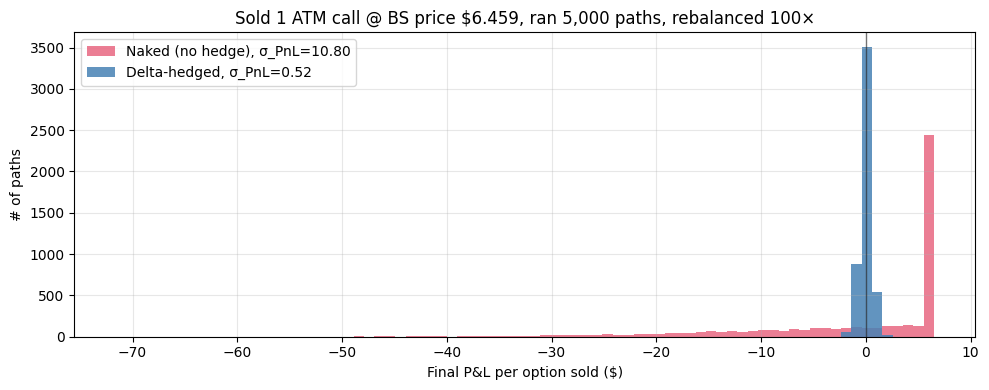

Naked  P&L:  mean = -1.018,  std = 10.804
Hedged P&L:  mean = +0.003,  std = 0.520
Variance reduction: 20.8× tighter

→ The naked seller has wild P&L despite charging the "fair" BS price — the price is fair only
  in expectation, not on every path. The hedger collapses to ~0. As n_steps → ∞, σ_hedged → 0 exactly.
  THAT is what licences the BS price: a hedger can replicate the payoff to arbitrary precision.


In [4]:
# Self-contained delta-hedging demo. Uses scipy.stats.norm imported in the Setup cell.
# We define a tiny inline BS call + delta so this section doesn't depend on cells below.

def _bs_call_demo(S, K, tau, r, sigma):
    if tau <= 0:
        return np.maximum(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

def _bs_delta_demo(S, K, tau, r, sigma):
    if tau <= 0:
        return (S > K).astype(float) if hasattr(S, '__iter__') else float(S > K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)

# Setup
S0_h, K_h        = 100.0, 100.0
mu_h, sig_h, r_h = 0.10, 0.30, 0.04
T_h              = 0.25                     # 3 months
n_steps_h        = 100                       # rebalance 100 times over T
n_paths_h        = 5_000
dt_h             = T_h / n_steps_h
rng_h            = np.random.default_rng(7)

# 1. Sell the call at its BS price.
C0 = _bs_call_demo(S0_h, K_h, T_h, r_h, sig_h)

# 2. Simulate stock paths under the REAL drift μ (not r). The BS argument should still work.
Z_h          = rng_h.standard_normal((n_paths_h, n_steps_h))
log_incs_h   = (mu_h - 0.5 * sig_h**2) * dt_h + sig_h * np.sqrt(dt_h) * Z_h
log_paths_h  = np.cumsum(log_incs_h, axis=1)
S_grid       = S0_h * np.exp(np.concatenate([np.zeros((n_paths_h, 1)), log_paths_h], axis=1))

# 3a. Naked P&L: receive C0, owe call payoff at expiry. Cash earns r over T.
payoff_h     = np.maximum(S_grid[:, -1] - K_h, 0.0)
pnl_naked    = C0 * np.exp(r_h * T_h) - payoff_h

# 3b. Delta-hedged P&L: rebalance Δ shares each step.
# Track cash balance. Buy Δ_0 shares at t=0 funded from cash. At each step,
# adjust holdings to new Δ_t, financing change at the (mid-period) stock price.
cash         = np.full(n_paths_h, C0)         # received from selling the call
shares       = np.zeros(n_paths_h)
for k in range(n_steps_h):
    tau_k    = T_h - k * dt_h
    delta_k  = _bs_delta_demo(S_grid[:, k], K_h, tau_k, r_h, sig_h)
    # Buy/sell shares to reach delta_k holdings, paying with cash.
    trade    = delta_k - shares
    cash    -= trade * S_grid[:, k]
    shares   = delta_k
    # Cash earns r over the next dt; shares move with the stock by themselves.
    cash    *= np.exp(r_h * dt_h)

# At expiry: liquidate shares, pay call payoff.
cash        += shares * S_grid[:, -1]
pnl_hedged   = cash - payoff_h

# Plot the two P&L distributions on the same axis for direct comparison.
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(min(pnl_naked.min(), pnl_hedged.min()),
                   max(pnl_naked.max(), pnl_hedged.max()), 80)
ax.hist(pnl_naked,  bins=bins, alpha=0.55, label=f'Naked (no hedge), σ_PnL={pnl_naked.std():.2f}',  color='crimson')
ax.hist(pnl_hedged, bins=bins, alpha=0.85, label=f'Delta-hedged, σ_PnL={pnl_hedged.std():.2f}',     color='steelblue')
ax.axvline(0, color='k', lw=1, alpha=0.5)
ax.set_xlabel('Final P&L per option sold ($)'); ax.set_ylabel('# of paths')
ax.set_title(f'Sold 1 ATM call @ BS price ${C0:.3f}, ran {n_paths_h:,} paths, rebalanced {n_steps_h}×')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Naked  P&L:  mean = {pnl_naked.mean():+.3f},  std = {pnl_naked.std():.3f}')
print(f'Hedged P&L:  mean = {pnl_hedged.mean():+.3f},  std = {pnl_hedged.std():.3f}')
print(f'Variance reduction: {(pnl_naked.std() / pnl_hedged.std()):.1f}× tighter')
print()
print('→ The naked seller has wild P&L despite charging the "fair" BS price — the price is fair only')
print('  in expectation, not on every path. The hedger collapses to ~0. As n_steps → ∞, σ_hedged → 0 exactly.')
print('  THAT is what licences the BS price: a hedger can replicate the payoff to arbitrary precision.')

## Implementation from scratch

Write the BS formula directly from the math above. NumPy-vectorise across `S` and `K`. (`T` is scalar; vectorise outside if you need term-structure batches.)

In [5]:
def black_scholes(S, K, T, r, sigma, option_type='call', q=0.0):
    """Black-Scholes-Merton price for a European call/put with continuous dividend yield."""
    if T <= 0:
        return np.maximum(S - K, 0.0) if option_type == 'call' else np.maximum(K - S, 0.0)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")


# Smoke test: Hull textbook ATM call (no dividend)
test_call = black_scholes(S=42, K=40, T=0.5, r=0.10, sigma=0.20, option_type='call', q=0.0)
print(f'Hull textbook ATM call (q=0): {test_call:.4f}  (expected: 4.7594)')

Hull textbook ATM call (q=0): 4.7594  (expected: 4.7594)


### Sanity check 1 — put-call parity

In [6]:
K_test, T_test, sigma_test = 280.0, T, 0.30
c = black_scholes(S0, K_test, T_test, r, sigma_test, 'call', q)
p = black_scholes(S0, K_test, T_test, r, sigma_test, 'put',  q)

lhs = c - p
rhs = S0 * np.exp(-q * T_test) - K_test * np.exp(-r * T_test)
print(f'C - P                = {lhs:.6f}')
print(f'S e^(-qT) - K e^(-rT) = {rhs:.6f}')
print(f'parity holds: {abs(lhs - rhs) < 1e-10}')

C - P                = 2.494067
S e^(-qT) - K e^(-rT) = 2.494067
parity holds: True


### Sanity check 2 — validate against QuantLib

In [7]:
import QuantLib as ql

def quantlib_bs(S, K, T, r, sigma, option_type, q):
    today    = ql.Date.todaysDate()
    maturity = today + int(round(T * 365))
    ql.Settings.instance().evaluationDate = today

    payoff_type = ql.Option.Call if option_type == 'call' else ql.Option.Put
    payoff      = ql.PlainVanillaPayoff(payoff_type, K)
    exercise    = ql.EuropeanExercise(maturity)
    option      = ql.VanillaOption(payoff, exercise)

    spot_h    = ql.QuoteHandle(ql.SimpleQuote(S))
    rate_ts   = ql.YieldTermStructureHandle(ql.FlatForward(today, r, ql.Actual365Fixed()))
    div_ts    = ql.YieldTermStructureHandle(ql.FlatForward(today, q, ql.Actual365Fixed()))
    vol_ts    = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, ql.NullCalendar(), sigma, ql.Actual365Fixed()))

    process = ql.BlackScholesMertonProcess(spot_h, div_ts, rate_ts, vol_ts)
    option.setPricingEngine(ql.AnalyticEuropeanEngine(process))
    return option.NPV()


rows = []
for K_ in [240, 280, 320]:
    for sig in [0.20, 0.30, 0.50]:
        for opt in ['call', 'put']:
            ours = black_scholes(S0, K_, T, r, sig, opt, q)
            ref  = quantlib_bs   (S0, K_, T, r, sig, opt, q)
            rows.append({'K': K_, 'sigma': sig, 'type': opt, 'ours': ours, 'QL': ref, 'diff': ours - ref})

pd.DataFrame(rows).round(8)

,K,sigma,type,ours,QL,diff
0,240,0.2,call,42.369036,42.369036,-0.0
1,240,0.2,put,0.006698,0.006698,-0.0
2,240,0.3,call,42.564654,42.564654,-0.0
3,240,0.3,put,0.202315,0.202315,-0.0
4,240,0.5,call,44.470715,44.470715,-0.0
5,240,0.5,put,2.108376,2.108376,-0.0
6,280,0.2,call,7.520846,7.520846,-0.0
7,280,0.2,put,5.026779,5.026779,0.0
8,280,0.3,call,10.589886,10.589886,-0.0
9,280,0.3,put,8.095819,8.095819,0.0


### Sanity check 3 — risk-neutral expectation matches closed-form

In [8]:
rng       = np.random.default_rng(42)
n_paths   = 1_000_000
sig_test  = 0.30
K_test_mc = 280.0

Z         = rng.standard_normal(n_paths)
ST        = S0 * np.exp((r - q - 0.5 * sig_test**2) * T + sig_test * np.sqrt(T) * Z)
mc_price  = np.exp(-r * T) * np.mean(np.maximum(ST - K_test_mc, 0))
mc_se     = (np.exp(-r * T) * np.maximum(ST - K_test_mc, 0)).std() / np.sqrt(n_paths)
bs_price  = black_scholes(S0, K_test_mc, T, r, sig_test, 'call', q)

print(f'BS closed-form:  {bs_price:.6f}')
print(f'MC (1M paths):   {mc_price:.6f}  (SE ≈ {mc_se:.6f})')
print(f't-statistic:     {(mc_price - bs_price)/mc_se:+.2f}σ from closed-form')

BS closed-form:  10.589886
MC (1M paths):   10.592187  (SE ≈ 0.015187)
t-statistic:     +0.15σ from closed-form


## Worked example — price the AAPL ATM call

In [9]:
calls_view = calls.assign(
    moneyness=lambda d: d['strike'] / S0,
    mid=lambda d: (d['bid'] + d['ask']) / 2,
).sort_values('moneyness')

atm_idx = (calls_view['strike'] - S0).abs().idxmin()
atm     = calls_view.loc[atm_idx]

K_atm   = atm['strike']
mkt_iv  = atm['impliedVolatility']
mkt_mid = atm['mid']

bs_price = black_scholes(S0, K_atm, T, r, mkt_iv, 'call', q)

print(f'ATM call: K={K_atm:.0f}  (moneyness {K_atm/S0:.3f})')
print(f'  yfinance impliedVolatility = {mkt_iv:.4f}')
print(f'  market mid quote           = {mkt_mid:.4f}')
print(f'  our BS(yfinance IV) price  = {bs_price:.4f}')
print(f'  diff vs mid                = {bs_price - mkt_mid:+.4f}')
print()
print('→ yfinance IV is computed against the LAST TRADE, not current mid.')
print('  Always invert IV from the mid against your own r/q assumptions (next cell).')

ATM call: K=280  (moneyness 0.994)
  yfinance impliedVolatility = 0.2543
  market mid quote           = 8.8000
  our BS(yfinance IV) price  = 9.1862
  diff vs mid                = +0.3862

→ yfinance IV is computed against the LAST TRADE, not current mid.
  Always invert IV from the mid against your own r/q assumptions (next cell).


### Inside the formula — `d1`, `d2`, `N(d1)`, `N(d2)` as actual numbers

`d1` and `d2` look like algebra. Let's see them as numbers for the AAPL call we just priced, so the formula stops being abstract. The point: each piece of `C = S·e^(-qT)·N(d1) − K·e^(-rT)·N(d2)` is a *price* — a discounted expected dollar amount — not a notation curiosity.

In [10]:
# Decompose the AAPL ATM call price into d1, d2, N(d1), N(d2), and the two cash terms.
sigma_used = mkt_iv          # use the IV we already inverted (yfinance reported value here)

d1 = (np.log(S0 / K_atm) + (r - q + 0.5 * sigma_used**2) * T) / (sigma_used * np.sqrt(T))
d2 = d1 - sigma_used * np.sqrt(T)

Nd1, Nd2 = norm.cdf(d1), norm.cdf(d2)

term_stock = S0 * np.exp(-q * T) * Nd1                 # "expected stock value if exercised, discounted"
term_cash  = K_atm * np.exp(-r * T) * Nd2              # "expected cash paid if exercised, discounted"
call_price = term_stock - term_cash

print(f'INPUTS:  S0 = {S0:.2f},  K = {K_atm:.0f},  T = {T:.4f}y ({T_days}d),  r = {r:.3f},  q = {q:.3f},  σ = {sigma_used:.4f}')
print()
print(f'  d1  =  [ln(S/K) + (r−q+½σ²)T] / (σ√T)  =  {d1:+.4f}')
print(f'  d2  =  d1 − σ√T                       =  {d2:+.4f}')
print()
print(f'  N(d1) = {Nd1:.4f}    ← this IS the call delta (after the e^(-qT) discount):  Δ = {np.exp(-q*T)*Nd1:.4f}')
print(f'  N(d2) = {Nd2:.4f}    ← this IS the risk-neutral probability the call ends in the money')
print()
print(f'  S·e^(-qT)·N(d1) = {S0:.2f} · {np.exp(-q*T):.4f} · {Nd1:.4f}  = ${term_stock:.4f}   (PV of stock leg)')
print(f'  K·e^(-rT)·N(d2) = {K_atm:.0f} · {np.exp(-r*T):.4f} · {Nd2:.4f}  = ${term_cash :.4f}   (PV of cash leg)')
print(f'  Call price       = ${term_stock:.4f} − ${term_cash:.4f}  = ${call_price:.4f}')
print()
print(f'Notice: ATM (K ≈ S) gives d1 > 0, so N(d1) > 0.5. The "ATM call has delta 0.5" myth dies here.')
print(f'For this 28-day call: delta is {np.exp(-q*T)*Nd1:.3f}, not 0.5.')

INPUTS:  S0 = 281.68,  K = 280,  T = 0.0767y (28d),  r = 0.043,  q = 0.005,  σ = 0.2543

  d1  =  [ln(S/K) + (r−q+½σ²)T] / (σ√T)  =  +0.1615
  d2  =  d1 − σ√T                       =  +0.0911

  N(d1) = 0.5642    ← this IS the call delta (after the e^(-qT) discount):  Δ = 0.5639
  N(d2) = 0.5363    ← this IS the risk-neutral probability the call ends in the money

  S·e^(-qT)·N(d1) = 281.68 · 0.9996 · 0.5642  = $158.8513   (PV of stock leg)
  K·e^(-rT)·N(d2) = 280 · 0.9967 · 0.5363  = $149.6651   (PV of cash leg)
  Call price       = $158.8513 − $149.6651  = $9.1862

Notice: ATM (K ≈ S) gives d1 > 0, so N(d1) > 0.5. The "ATM call has delta 0.5" myth dies here.
For this 28-day call: delta is 0.564, not 0.5.


### Visual — call delta across moneyness

Delta is the slope of the call-price curve in `S`. Equivalently, $\Delta = e^{-q\tau} N(d_1)$. The chart below sweeps strike from deep ITM to deep OTM and shows where ATM sits — clearly **above 0.5**. The shift gets larger with longer `T` and higher `σ` (more drift in `d1`).

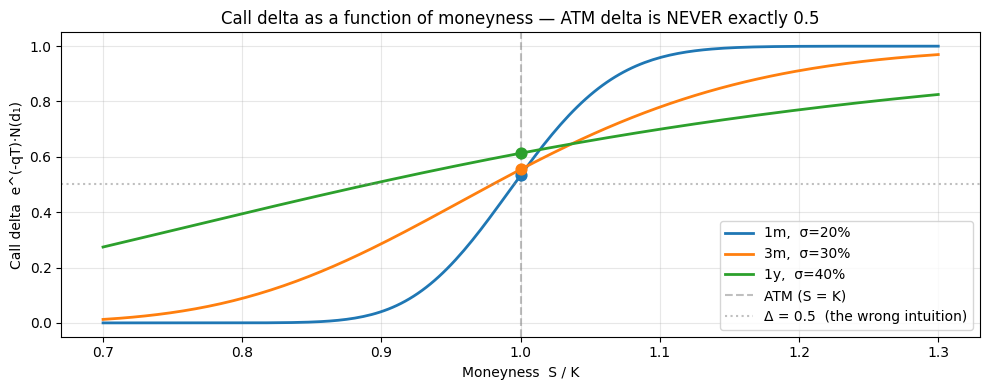

At each ATM dot, delta sits above 0.5 — by more for longer T and higher σ.
That offset is the σ²/2 term in d1: even at S=K, the lognormal mean of S_T is above K, tilting exercise probability higher.


In [11]:
# Call delta vs moneyness (S/K) under three (T, σ) configurations.
moneyness = np.linspace(0.7, 1.3, 200)        # S/K
S_sweep   = 100.0                              # fix S, vary K
K_sweep   = S_sweep / moneyness

cases = [
    ('1m,  σ=20%', 1/12, 0.20),
    ('3m,  σ=30%', 0.25, 0.30),
    ('1y,  σ=40%', 1.00, 0.40),
]

fig, ax = plt.subplots(figsize=(10, 4))
for label, T_c, sig_c in cases:
    d1_c     = (np.log(S_sweep / K_sweep) + (r - q + 0.5 * sig_c**2) * T_c) / (sig_c * np.sqrt(T_c))
    delta_c  = np.exp(-q * T_c) * norm.cdf(d1_c)
    ax.plot(moneyness, delta_c, lw=2, label=label)
    # Mark ATM (S = K) point on each curve.
    d1_atm   = (np.log(1) + (r - q + 0.5 * sig_c**2) * T_c) / (sig_c * np.sqrt(T_c))
    ax.scatter([1.0], [np.exp(-q * T_c) * norm.cdf(d1_atm)], s=60, zorder=5)

ax.axvline(1.0, color='gray', ls='--', alpha=0.5, label='ATM (S = K)')
ax.axhline(0.5, color='gray', ls=':',  alpha=0.5, label='Δ = 0.5  (the wrong intuition)')
ax.set_xlabel('Moneyness  S / K'); ax.set_ylabel('Call delta  e^(-qT)·N(d₁)')
ax.set_title('Call delta as a function of moneyness — ATM delta is NEVER exactly 0.5')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('At each ATM dot, delta sits above 0.5 — by more for longer T and higher σ.')
print('That offset is the σ²/2 term in d1: even at S=K, the lognormal mean of S_T is above K, tilting exercise probability higher.')

## Implied volatility — invert BS for σ

Three production-grade subtleties: (1) lower bound is **discounted intrinsic** ($Se^{-q\tau} - Ke^{-r\tau}$), not raw intrinsic; (2) Brent works but production seeds Newton with the Brenner-Subrahmanyam approximation $\sigma_0 \approx \sqrt{2\pi/\tau} \cdot C/S$; (3) cap iterations for near-flat-vega regions.

In [12]:
def implied_vol(price, S, K, T, r, option_type='call', q=0.0,
                lo=1e-6, hi=5.0, maxiter=100):
    """Brent root-find for IV. Returns NaN if outside [lo, hi] or below discounted intrinsic."""
    if option_type == 'call':
        lower_bound = max(S * np.exp(-q * T) - K * np.exp(-r * T), 0.0)
    else:
        lower_bound = max(K * np.exp(-r * T) - S * np.exp(-q * T), 0.0)
    if price < lower_bound - 1e-10:
        return np.nan

    f = lambda sig: black_scholes(S, K, T, r, sig, option_type, q) - price
    if f(lo) > 0 or f(hi) < 0:
        return np.nan
    return brentq(f, lo, hi, xtol=1e-8, maxiter=maxiter)


sigma_in  = 0.32
price_in  = black_scholes(S0, 280.0, T, r, sigma_in, 'call', q)
sigma_out = implied_vol(price_in, S0, 280.0, T, r, 'call', q)
print(f'sigma in:  {sigma_in:.6f}')
print(f'price:     {price_in:.6f}')
print(f'sigma out: {sigma_out:.6f}  (round-trip error: {abs(sigma_in-sigma_out):.2e})')

my_iv_atm = implied_vol(mkt_mid, S0, K_atm, T, r, 'call', q)
print(f'\nAAPL K={K_atm:.0f} ATM mid = {mkt_mid:.4f}')
print(f'  yfinance IV               = {mkt_iv:.4f}')
print(f'  our IV (mid + our r,q,T)  = {my_iv_atm:.4f}')

sigma in:  0.320000
price:     11.205482
sigma out: 0.320000  (round-trip error: 7.31e-12)

AAPL K=280 ATM mid = 8.8000
  yfinance IV               = 0.2543
  our IV (mid + our r,q,T)  = 0.2418


## The vol smile — empirical evidence BS is wrong

If BS held, all strikes would have the same IV. They don't. Far OTM strikes carry higher vol than ATM — fatter tails than GBM allows. Production desks use **stochastic vol** (Heston, SABR) or **local vol** (Dupire). See `02_bs_family_and_asset_classes.ipynb` for SABR.

Filter by spread before plotting — wide bid-ask makes the mid meaningless on illiquid wings.

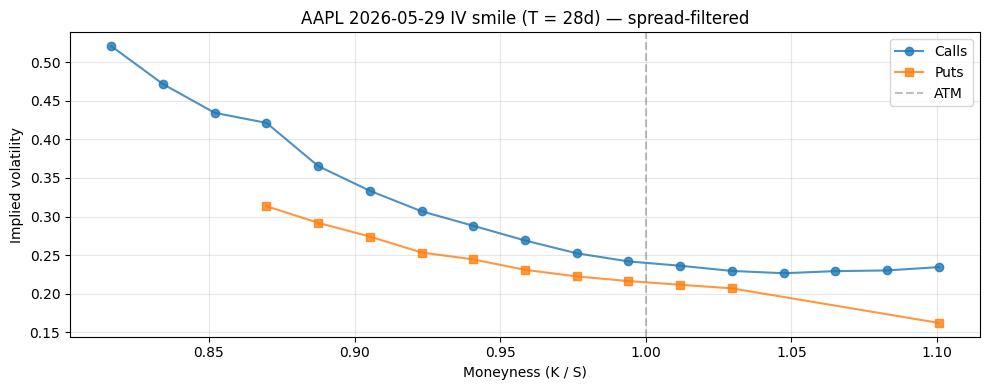

→ 17 call quotes / 11 put quotes survived the 10% spread filter.


In [13]:
def market_iv_from_mid(row, opt, max_rel_spread=0.10):
    bid, ask = row['bid'], row['ask']
    if bid == 0 or ask == 0:
        return np.nan
    mid = (bid + ask) / 2
    if (ask - bid) / mid > max_rel_spread:
        return np.nan
    return implied_vol(mid, S0, row['strike'], T, r, opt, q)

calls_iv = calls.assign(our_iv=lambda d: d.apply(market_iv_from_mid, axis=1, opt='call'))
puts_iv  = puts .assign(our_iv=lambda d: d.apply(market_iv_from_mid, axis=1, opt='put'))

band_lo, band_hi = 0.80 * S0, 1.20 * S0
c_band = calls_iv.query('@band_lo <= strike <= @band_hi').dropna(subset=['our_iv'])
p_band = puts_iv .query('@band_lo <= strike <= @band_hi').dropna(subset=['our_iv'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(c_band['strike'] / S0, c_band['our_iv'], 'o-', label='Calls', alpha=0.8)
ax.plot(p_band['strike'] / S0, p_band['our_iv'], 's-', label='Puts',  alpha=0.8)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5, label='ATM')
ax.set_xlabel('Moneyness (K / S)'); ax.set_ylabel('Implied volatility')
ax.set_title(f'AAPL {expiry} IV smile (T = {T_days}d) — spread-filtered')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'→ {len(c_band)} call quotes / {len(p_band)} put quotes survived the 10% spread filter.')

### What BS actually predicts vs what we see

Re-plot the smile with the BS prediction overlaid. BS assumes one constant `σ`, so its prediction is a **horizontal line** — every strike at the same vol. The market is clearly not horizontal: OTM puts are richer (downside crash insurance), and the slope tells you how much. **The gap between the flat line and the smile *is* the BS modelling error**, in implied-vol units.

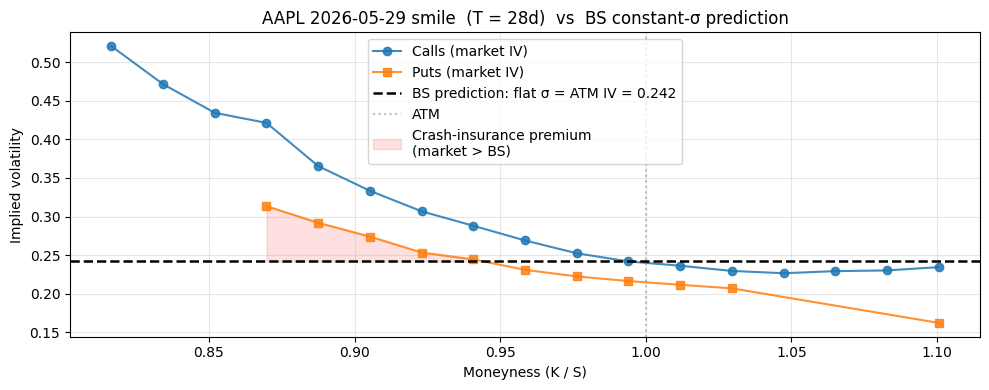

BS-implied flat IV anchor (ATM): 0.2418
Lowest-strike put IV          : 0.3134
Skew premium at far OTM put   : +7.17 vol points above BS

→ If BS were correct, the two curves would lie on the dashed line. The gap is the model error.
  Heston/SABR/local-vol fit smiles like this; Heston is in 07_heston.ipynb.


In [14]:
# Same smile, with BS prediction (flat at ATM IV) overlaid for direct visual comparison.
# Anchor the BS-prediction line at the ATM call IV (whichever survived the spread filter closest to S0).
atm_row    = c_band.iloc[(c_band['strike'] - S0).abs().argmin()]
atm_iv_bs  = atm_row['our_iv']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(c_band['strike'] / S0, c_band['our_iv'], 'o-', label='Calls (market IV)', alpha=0.85)
ax.plot(p_band['strike'] / S0, p_band['our_iv'], 's-', label='Puts (market IV)',  alpha=0.85)
ax.axhline(atm_iv_bs, color='black', ls='--', lw=1.8,
           label=f'BS prediction: flat σ = ATM IV = {atm_iv_bs:.3f}')
ax.axvline(1.0, color='gray', ls=':', alpha=0.5, label='ATM')

# Shade the gap between market IV and BS prediction on the put wing — the "skew premium".
p_sorted = p_band.sort_values('strike')
ax.fill_between(p_sorted['strike'] / S0, p_sorted['our_iv'], atm_iv_bs,
                where=(p_sorted['our_iv'] > atm_iv_bs),
                color='red', alpha=0.12, label='Crash-insurance premium\n(market > BS)')

ax.set_xlabel('Moneyness (K / S)'); ax.set_ylabel('Implied volatility')
ax.set_title(f'AAPL {expiry} smile  (T = {T_days}d)  vs  BS constant-σ prediction')
ax.legend(loc='upper center'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Quantify the gap.
put_skew_pp = (p_sorted['our_iv'].iloc[0] - atm_iv_bs) * 100
print(f'BS-implied flat IV anchor (ATM): {atm_iv_bs:.4f}')
print(f'Lowest-strike put IV          : {p_sorted["our_iv"].iloc[0]:.4f}')
print(f'Skew premium at far OTM put   : +{put_skew_pp:.2f} vol points above BS')
print()
print('→ If BS were correct, the two curves would lie on the dashed line. The gap is the model error.')
print('  Heston/SABR/local-vol fit smiles like this; Heston is in 07_heston.ipynb.')

## Black-76 — the forward-price formulation

For options on **forwards or futures** (FX, rates, commodities), there's no underlying spot to discount. Black's 1976 modification swaps the spot $S$ for the forward $F$ and drops the dividend yield:

$$\boxed{\; C = e^{-r\tau} \big[ F \, N(d_1) - K \, N(d_2) \big] \;}$$

$$d_1 = \frac{\ln(F/K) + \tfrac{1}{2}\sigma^2 \tau}{\sigma\sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}$$

Algebraically equivalent to BS-Merton with $F = S e^{(r-q)\tau}$. **Swaptions, caps/floors, FX options all use Black-76 directly.**

> **Interview note**: AM and rates-desk candidates *will* be asked Black-76 even before BS-Merton with continuous dividends.

In [15]:
def black_76(F, K, T, r, sigma, option_type='call'):
    """Black-76 formula for options on forwards / futures."""
    if T <= 0:
        return np.maximum(F - K, 0.0) if option_type == 'call' else np.maximum(K - F, 0.0)

    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    df = np.exp(-r * T)

    if option_type == 'call':
        return df * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return df * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


F_implied = S0 * np.exp((r - q) * T)
b76 = black_76(F_implied, 280.0, T, r, 0.30, 'call')
bsm = black_scholes(S0,    280.0, T, r, 0.30, 'call', q)
print(f'Black-76 (F={F_implied:.4f}):  {b76:.6f}')
print(f'BS-Merton (S={S0:.4f}, q={q}): {bsm:.6f}')
print(f'identical to: {abs(b76 - bsm):.2e}')

Black-76 (F=282.5023):  10.589886
BS-Merton (S=281.6800, q=0.005): 10.589886
identical to: 4.26e-14


## Boundary behaviour — sanity checks

| Limit | Behaviour |
|---|---|
| $\tau \to 0$ | $C \to \max(S-K, 0)$ |
| $\sigma \to 0$ | $C \to \max(S e^{-q\tau} - K e^{-r\tau}, 0)$ |
| $\sigma \to \infty$ | $C \to S e^{-q\tau}$, $\;P \to K e^{-r\tau}$ (via parity) |
| $S \to 0$ | $C \to 0$, $\;P \to K e^{-r\tau}$ |
| $S \to \infty$ | $C \to S e^{-q\tau}$, $\;P \to 0$ |

In [16]:
K_, r_, q_, T_ = 100, 0.05, 0.0, 0.5

print('Limit checks (call):')
print(f'  T → 0   |  S=120,K=100:   {black_scholes(120, K_, 1e-9, r_, 0.3, "call", q_):.4f}  (intrinsic = 20)')
print(f'  σ → 0   |  S=110,K=100:   {black_scholes(110, K_, T_, r_, 1e-9, "call", q_):.4f}  (forward-discounted = {max(110-100*np.exp(-r_*T_),0):.4f})')
print(f'  σ → ∞   |  S=K=100:       {black_scholes(100, K_, T_, r_, 100, "call", q_):.4f}  (→ S = 100)')
print(f'  S → 0:                    {black_scholes(1e-6, K_, T_, r_, 0.3, "call", q_):.4f}  (→ 0)')
print(f'  σ → ∞ put |  S=K=100:     {black_scholes(100, K_, T_, r_, 100, "put", q_):.4f}  (→ K e^(-rT) = {K_ * np.exp(-r_*T_):.4f})')

Limit checks (call):
  T → 0   |  S=120,K=100:   20.0000  (intrinsic = 20)
  σ → 0   |  S=110,K=100:   12.4690  (forward-discounted = 12.4690)
  σ → ∞   |  S=K=100:       100.0000  (→ S = 100)
  S → 0:                    0.0000  (→ 0)
  σ → ∞ put |  S=K=100:     97.5310  (→ K e^(-rT) = 97.5310)


## Exercises

Try each from a blank cell **before** revealing the solution. Recognition collapses under retrieval; only recall survives.

### Exercise 1 — Vectorise across strikes

Compute the call price for an array of 100 strikes between $0.5 \cdot S_0$ and $1.5 \cdot S_0$ at $\sigma = 0.30$, $T = 0.25$, $r = 0.04$, $q = 0$. Plot price vs strike. Confirm monotone-decreasing and convex.

In [17]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
K_grid = np.linspace(0.5 * S0, 1.5 * S0, 100)
prices = black_scholes(S=S0, K=K_grid, T=0.25, r=0.04, sigma=0.30, option_type='call', q=0)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(K_grid, prices, lw=2)
ax.axvline(S0, color='gray', ls='--', alpha=0.5, label='ATM')
ax.set_xlabel('Strike K'); ax.set_ylabel('BS call price'); ax.set_title('Call price vs strike')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'monotone decreasing: {(np.diff(prices) < 0).all()}')
print(f'convex (Δ² ≥ 0): {(np.diff(prices, n=2) >= -1e-10).all()}')
```

_Smooth decreasing convex curve. Both checks True._

</details>

### Exercise 2 — Verify put-call parity from market data

Take all strikes in the AAPL chain that have both call and put quotes with non-zero bid. For each, check that $C_{mid} - P_{mid} \approx S_0 e^{-q\tau} - K e^{-r\tau}$ holds to within 1% relative error. Where it fails, why?

In [18]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
calls_p = calls.assign(call_mid=lambda d: (d['bid'] + d['ask']) / 2)
puts_p  = puts .assign(put_mid =lambda d: (d['bid'] + d['ask']) / 2)
paired = calls_p[['strike', 'call_mid', 'bid']].merge(
    puts_p[['strike', 'put_mid', 'bid']], on='strike', suffixes=('_c', '_p'))
paired = paired[(paired['bid_c'] > 0) & (paired['bid_p'] > 0)]
paired = paired.assign(
    lhs = lambda d: d['call_mid'] - d['put_mid'],
    rhs = lambda d: S0 * np.exp(-q * T) - d['strike'] * np.exp(-r * T),
)
paired['rel_err'] = (paired['lhs'] - paired['rhs']).abs() / paired['rhs'].abs()
print(paired[['strike', 'lhs', 'rhs', 'rel_err']].round(4).to_string(index=False))
print(f"\nstrikes within 1% parity: {(paired['rel_err'] < 0.01).sum()} / {len(paired)}")
```

_Wide bid-ask + AAPL borrow frictions blow up parity at the wings._

</details>

### Exercise 3 — IV smile slope

Compute $\partial \sigma_{IV} / \partial K$ near ATM (5-point central difference on calls within ±5% of spot). Is it negative (equity skew) or symmetric? What does that imply about the market's view of downside risk?

In [19]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
near_atm = c_band.query('@S0*0.95 <= strike <= @S0*1.05').sort_values('strike').reset_index(drop=True)
if len(near_atm) >= 5:
    K_arr  = near_atm['strike'].values
    iv_arr = near_atm['our_iv'].values
    mid    = len(K_arr) // 2
    slope  = (iv_arr[mid+1] - iv_arr[mid-1]) / (K_arr[mid+1] - K_arr[mid-1])
    print(f'Near-ATM IV slope ∂σ/∂K = {slope:+.6f} per $1 strike')
    print(f'Slope in moneyness     = {slope * S0:+.4f} per 100% moneyness')
    if slope < 0:
        print('→ Negative: equity-style skew. Markets price downside more expensively.')
else:
    print('Not enough quotes near ATM')
```

_Negative slope on equity. Crash insurance premium._

</details>

### Exercise 4 — Brenner-Subrahmanyam initial guess

The closed-form ATM-near IV approximation is $\sigma_0 \approx \sqrt{2\pi/\tau} \cdot C / S$. Implement it. Compare its accuracy to your Brent solver across 10 strikes. Best near ATM, degrades on the wings — that's why production uses it as a Newton seed, not a final answer.

In [20]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
def brenner_subrahmanyam(price, S, T):
    return np.sqrt(2 * np.pi / T) * price / S

near_atm_strikes = sorted(c_band['strike'].values, key=lambda k: abs(k - S0))[:10]
rows = []
for K_ in near_atm_strikes:
    row = c_band.query('strike == @K_').iloc[0]
    mid = (row['bid'] + row['ask']) / 2
    iv_bs    = brenner_subrahmanyam(mid, S0, T)
    iv_brent = implied_vol(mid, S0, K_, T, r, 'call', q)
    rows.append({'K': K_, 'mid': mid, 'iv_BS_approx': iv_bs, 'iv_brent': iv_brent,
                 'abs_err': abs(iv_bs - iv_brent)})
iv_compare = pd.DataFrame(rows).round(4)
print(iv_compare.to_string(index=False))
print(f'\nMean abs error: {iv_compare["abs_err"].mean():.4f}')
```

_Accurate at ATM (ITM/OTM bias grows with |K - S|). Use as Newton seed, not final answer._

</details>

### Exercise 5 — Forward parity (MC verification)

Show numerically that the BS call price equals $e^{-r\tau} \cdot \mathbb{E}^Q[\max(S_T - K, 0)]$ where $\ln S_T$ is normal under Q. Sample 200,000 paths and average.

In [21]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
rng = np.random.default_rng(42)
n_paths = 200_000
S0_, K_, r_, q_, sig, T_ = 100, 100, 0.05, 0.02, 0.30, 0.5

Z   = rng.standard_normal(n_paths)
ST  = S0_ * np.exp((r_ - q_ - 0.5 * sig**2) * T_ + sig * np.sqrt(T_) * Z)
mc_price = np.exp(-r_ * T_) * np.mean(np.maximum(ST - K_, 0))
bs_price = black_scholes(S0_, K_, T_, r_, sig, 'call', q_)
print(f'BS  closed-form: {bs_price:.4f}')
print(f'MC (200k paths): {mc_price:.4f}')
```

_MC and BS agree to within MC standard error._

</details>

### Exercise 6 — N(d₂) interpretation

Compute $N(d_2)$ for a 30%-vol, 6-month, ATM call with $r = 5\%$, $q = 0$. Then run a Monte Carlo and count what fraction of paths finish $S_T > K$. They should match. (This is the textbook "$N(d_2)$ = risk-neutral exercise probability" check.)

In [22]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
S0_, K_, r_, q_, sig, T_ = 100, 100, 0.05, 0.0, 0.30, 0.5
d1 = (np.log(S0_/K_) + (r_ - q_ + 0.5*sig**2)*T_) / (sig*np.sqrt(T_))
d2 = d1 - sig*np.sqrt(T_)
N_d2_analytic = norm.cdf(d2)

rng = np.random.default_rng(42)
n_paths = 1_000_000
Z = rng.standard_normal(n_paths)
ST = S0_ * np.exp((r_ - q_ - 0.5*sig**2)*T_ + sig*np.sqrt(T_)*Z)
mc_prob_itm = np.mean(ST > K_)

print(f'N(d2) analytic = {N_d2_analytic:.6f}  ← Q(S_T > K)')
print(f'MC fraction ITM = {mc_prob_itm:.6f}')
print(f'\nN(d1) = {norm.cdf(d1):.6f} ≠ N(d2). Same probability, different measure.')
```

_N(d2) ≈ MC fraction ITM. N(d1) is the same probability under stock-numéraire._

</details>

## Interview Q&A

**Q: Derive the BS PDE.**

A: Build $\Pi = V - \Delta S$. Apply Itô to $V$. Choose $\Delta = \partial_S V$ — kills the $dW$ term. Remaining drift, by no-arbitrage, equals $r\Pi$. Gives $\partial_t V + \tfrac{1}{2}\sigma^2 S^2 \partial_{SS} V + r S \partial_S V - rV = 0$. The choice of $\Delta$ is *why* μ doesn't appear.

**Q: Why does the BS price depend on σ but not μ?**

A: Replication. The portfolio $\Pi = V - \Delta S$ with $\Delta = \partial_S V$ is **locally riskless**, regardless of how the stock drifts. By no-arbitrage, anything riskless earns $r$. Volatility doesn't cancel because it determines the **second-moment cost** of dynamic re-hedging.

**Q: What is N(d₂)? What is N(d₁)? Same probability?**

A: Different measures, same event.
- $N(d_2) = \mathbb{Q}(S_T > K)$ — risk-neutral probability of exercise.
- $N(d_1) = \mathbb{Q}^S(S_T > K)$ — same event under the **stock-numéraire** measure. $S e^{-q\tau} N(d_1)$ is the expected discounted stock value conditional on exercise. The change of measure tilts probability toward higher-S paths.

**Q: What's the delta of an ATM call?**

A: Not 0.5. Delta $= e^{-q\tau} N(d_1)$, and ATM $d_1 = \tfrac{1}{2}\sigma\sqrt{\tau} > 0$, so $N(d_1) > 0.5$. For 1y, σ=30%, ATM, q=0: delta ≈ 0.56.

**Q: Derive put-call parity.**

A: Static replication: long call + short put + short stock (with re-investment) + long bond paying $K$. Pays exactly zero in every state at expiry. Time-0 cost is zero: $C - P = S e^{-q\tau} - K e^{-r\tau}$. **No model assumption** beyond no-arbitrage.

**Q: Suppose interest rates rise. What happens to call/put prices?**

A: Non-dividend stocks: calls rise, puts fall. "Deferred-purchase" intuition. Algebraically $\rho_{call} = K\tau e^{-r\tau} N(d_2) > 0$. **Carve-out**: high-q stocks, the cost of carry $r-q$ matters more — sign argument can flip.

**Q: Price an American call.**

A: Non-dividend stock: never optimal to early-exercise (Merton 1973), so American call = European call. Dividend stock: early-exercise can be optimal just before ex-date. Methods: binomial trees, free-boundary PDE, Longstaff-Schwartz MC. See `03_binomial_trees.ipynb`.

**Q: Why is BS bad for path-dependent options (Asian, barrier, lookback)?**

A: BS prices payoffs depending only on $S_T$. Path-dependent payoffs depend on the trajectory. Options: (a) MC under Q (universal); (b) PDE with extra state variable (works for some); (c) closed-form approximations (Levy for arithmetic Asians). MC is the universal hammer.

**Q: How do you hedge a short option position with discrete rebalancing?**

A: Continuous-time delta hedging eliminates risk; discrete leaves $\tfrac{1}{2}\Gamma (\Delta S)^2 - \theta \Delta t$ per period — the **gamma-theta trade-off**. Long gamma profits from realised vol; long theta pays for it. Realised vs implied is the bet.

**Q: Derive Black-76.**

A: BS-Merton with the underlying being the forward $F$, not spot. $F$ contains the carry, so no $S e^{-q\tau}$ — just $e^{-r\tau} F$. $C = e^{-r\tau}[F N(d_1) - K N(d_2)]$ with $d_1 = [\ln(F/K) + \tfrac{1}{2}\sigma^2\tau] / (\sigma\sqrt{\tau})$. Used for swaptions, caps/floors, FX, commodities.

**Q: What's the implied vol of a digital (binary) call?**

A: Digital pays \$1 if $S_T > K$. Its risk-neutral price is $e^{-r\tau} N(d_2)$ — the natural application of $N(d_2)$. Digitals are sensitive to **skew** ($\partial \sigma / \partial K$), not just $\sigma$ — smile-aware desks use a "skew-corrected digital".

**Q: What's the first thing to check when production says "BS doesn't match market"?**

A: In order: (1) day count — calendar vs trading? (2) Discount curve — OIS, Treasury, IBOR? (3) Dividends — discrete vs continuous, ex-dates? (4) Forward-IV vs spot-IV (sticky-strike vs sticky-delta)? (5) Settlement — T+0/T+1/T+2? **(6)** is the model question — usually fixed by step 5.

## Pitfalls reference card

| Pitfall | What goes wrong | Fix |
|---|---|---|
| Day-count mismatch | Mixing `T = days/360` and `T = days/365` | Pick one (Actual/365 in equity, varies in FI) and stick |
| Discrete vs continuous compounding | Quoting `r` as discrete annual but using `exp(-r*T)` | Convert: $r_{cc} = \ln(1 + r_{simple})$ |
| Calendar vs trading days for vol scaling | σ is annualised on **252** trading days, not 365 calendar | Use $\tau = $ trading days / 252 when scaling vol |
| **Variance is additive, vol is not** | Adding 1M σ + 2M σ to estimate 3M σ | Algebra in **variance**: $\sigma_{3M}^2 \tau_{3M} = \sigma_{1M}^2 \tau_{1M} + \sigma_{fwd}^2 \tau_{fwd}$ |
| Forgetting dividends | `q=0` for dividend stocks → systematic ATM mispricing | Continuous yield, or forward-adjusted spot for discrete divs |
| Using T-bill instead of OIS/SOFR | Equity options discount on the **collateralised** curve | OIS/SOFR for cleared/CSA-collateralised; Treasury is teaching proxy |
| Implied vs realised vol | Treating BS as descriptive ("σ measures vol") | They agree only in long-run average — gamma trade is the bet |
| `T = 0` | Division by zero in `d1` | Branch; return intrinsic |
| Negative IV from below-intrinsic quote | Brent fails on stale quotes priced below discounted intrinsic | Pre-check `price >= max(Se^{-qτ} - Ke^{-rτ}, 0)` |
| Calling `norm.cdf` in a Python loop | 1000× slowdown | NumPy-vectorise; `scipy.stats.norm.cdf` broadcasts |
| Single-σ pricing of a real book | Systematic skew exposure | Calibrate per-expiry smile (`05_implied_vol_surface.ipynb`) |
| Mid-quote on illiquid OTM | Wide bid-ask makes mid noise | Filter by `(ask - bid) / mid < threshold` |
| **Sticky-strike vs sticky-delta** dynamics | Wrong P&L attribution under spot moves | Sticky-strike: each strike's IV constant in $S$. Sticky-delta: each delta's IV constant. Real-world is a mix — measure |
| **Vanna/volga ignored in skew-heavy book** | Pure δ+γ hedging on smile-rich product → missed P&L from $\partial^2 V/\partial S\partial\sigma$ and $\partial^2 V/\partial\sigma^2$ | Add vanna and volga to the Greek set |
| AAPL discrete dividends inside option life | Continuous q misses the ex-date drop | **Escrowed-dividend model**: $S^* = S - \sum_i D_i e^{-r t_i}$, BS on $S^*$ |
| yfinance bid/ask quality | No NBBO guarantee, often stale | Production uses OPRA-derived top-of-book |

## What you've earned

After this notebook you can:

1. **Derive** the BS PDE from delta-hedging in 5 minutes on a whiteboard.
2. **Derive** BS via risk-neutral expectation, citing FTAP and Girsanov.
3. **Implement** the closed-form formula from memory, vectorised across strikes.
4. **Validate** against QuantLib to ~1e-10.
5. **Invert** to implied vol via Brent, with discounted-intrinsic lower bound and Brenner-Subrahmanyam seed.
6. **Identify** the smile in real market data and explain *why* it's there.
7. **Explain** $N(d_1)$ vs $N(d_2)$ as different-measure probabilities of the same event.
8. **Derive** Black-76 and switch between BS-Merton and Black-76 fluently.
9. **Defend** the model in interview — what works, what doesn't, what production uses instead.

Next: **`02_bs_family_and_asset_classes.ipynb`** for Bachelier, SABR, FX (Garman-Kohlhagen) with real EUR/USD data, and rates options (caplets, swaptions) with a real SOFR curve. Then **`03_greeks.ipynb`** for δ, γ, ν, θ, ρ + vanna/volga/charm.